IMPORTING DEPENDENCIES

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


LOADING THE DATASET

In [ ]:
df=pd.read_csv("/content/insurance.csv")

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


PERFORMING EXPLORATORY DATA ANALYSIS

In [ ]:
# Check shape and missing values
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (1338, 7)

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print("\nStatistical Summary:\n", df.describe())



Statistical Summary:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


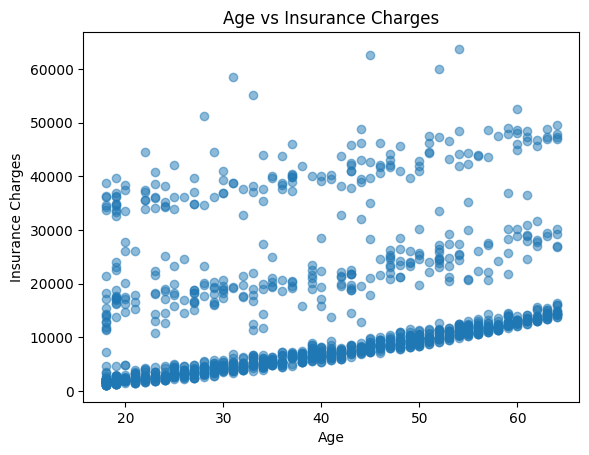

In [ ]:
#AGE VS CHARGES
plt.scatter(df['age'], df['charges'], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.show()


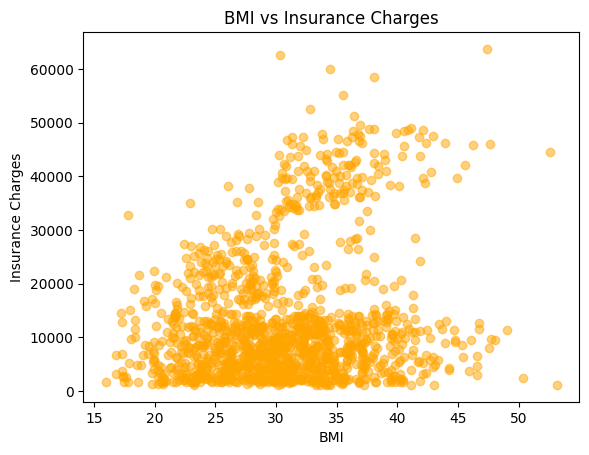

In [ ]:
#BMI VS CHARGES
plt.scatter(df['bmi'], df['charges'], color='orange', alpha=0.5)
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()


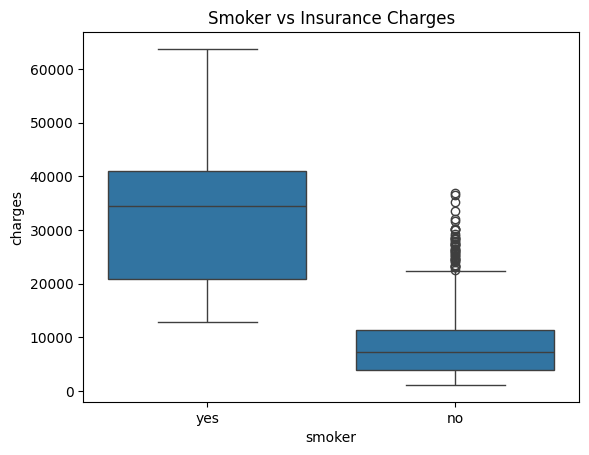

In [ ]:
#SMOKER VS CHARGES
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()


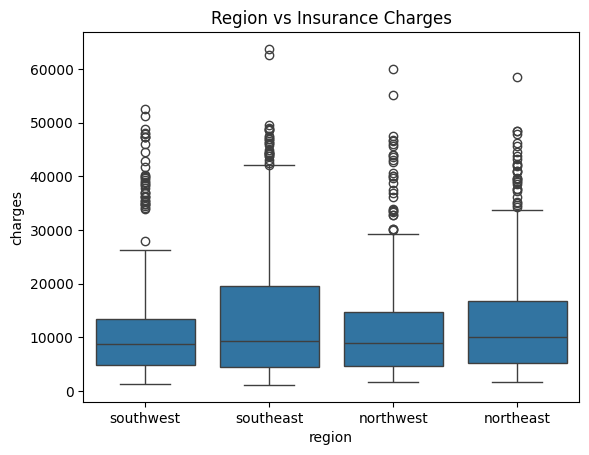

In [ ]:
#REGION VS CHARGES
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Insurance Charges")
plt.show()


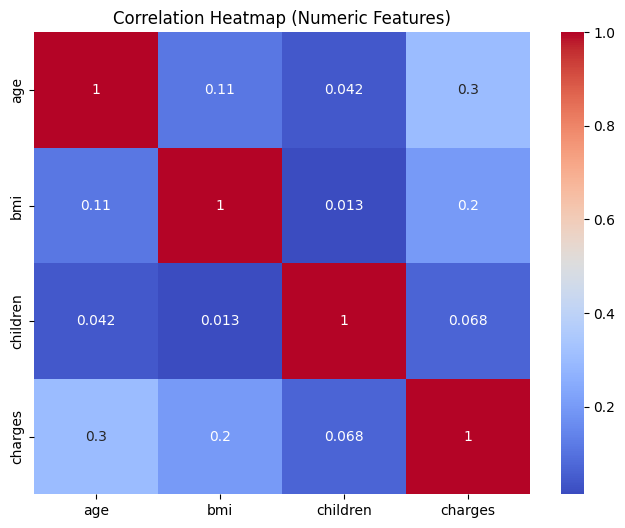

In [ ]:
#CORRELATION HEATMAP
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()



DATA PREPROCESSING

In [ ]:
# One-hot encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded Data Sample:")
print(df_encoded.head())


Encoded Data Sample:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
# Split features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (1338, 8)
Target vector shape: (1338,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (1070, 8)
Testing data shape: (268, 8)


MODEL BUILDING-LINEAR REGRESSION

In [ ]:
#Import Linear Regression Model
from sklearn.linear_model import LinearRegression


In [ ]:
#Create the Model Object
model = LinearRegression()
model


LinearRegression()

In [ ]:
#Train (Fit) the Model
model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


MODEL EVALUATION & PREDICTIONS

In [ ]:
# Predict insurance charges
y_pred = model.predict(X_test)
y_pred


array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673494, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [ ]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)



Model Evaluation Metrics:
Mean Absolute Error (MAE): 4181.19447375365
Root Mean Squared Error (RMSE): 5796.284659276273
R² Score: 0.7835929767120724


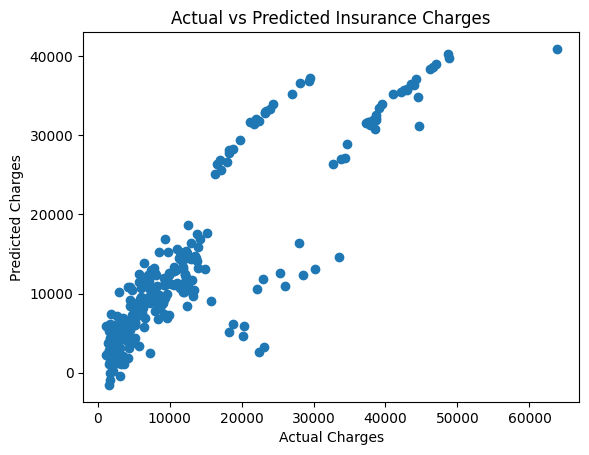

In [ ]:
#ACTUAL VS PREDICTED VISUALIZATION
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()


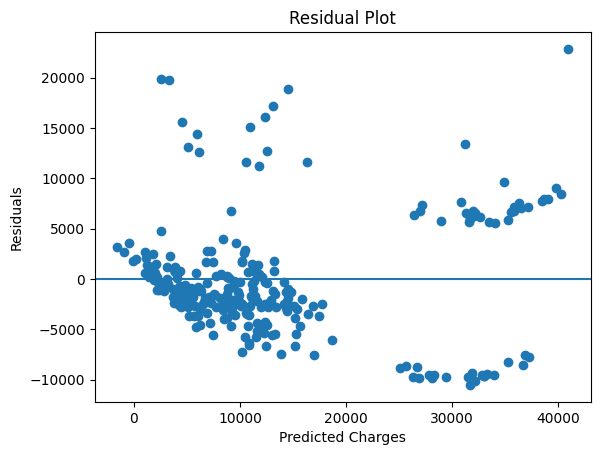

In [ ]:
#RESIDUAL PLOT
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


MODEL INTERPRETATION (Feature Impact)

In [ ]:
# Model coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Impact on Insurance Charges:")
print(coeff_df.sort_values(by="Coefficient", ascending=False))



Feature Impact on Insurance Charges:
            Feature   Coefficient
4        smoker_yes  23651.128856
2          children    425.278784
1               bmi    337.092552
0               age    256.975706
3          sex_male    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


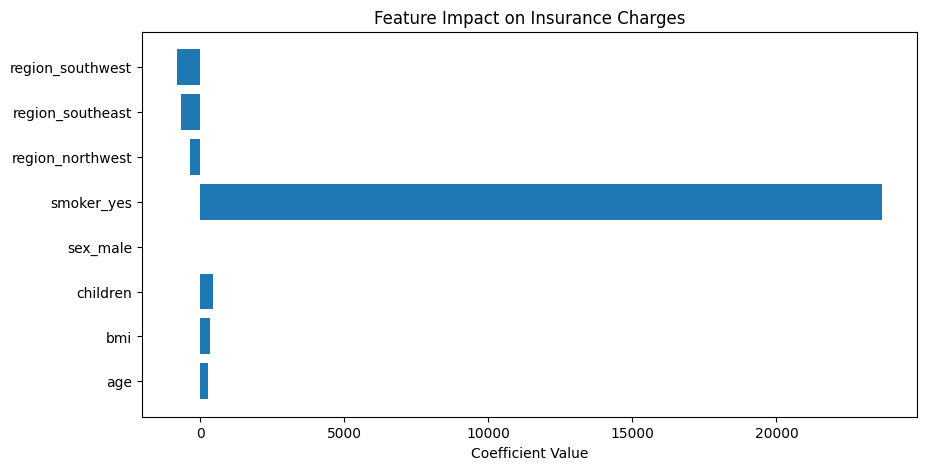

In [ ]:
#FEATURE IMPORTANCE
plt.figure(figsize=(10,5))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Feature Impact on Insurance Charges")
plt.show()


USER INPUT PREDICTION

In [ ]:
#Take User Inputs
print("\n--- Insurance Cost Prediction ---")

age = int(input("Enter age: "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter number of children: "))

sex = input("Enter sex (male/female): ").lower()
smoker = input("Smoker? (yes/no): ").lower()
region = input("Enter region (northwest/southeast/southwest/northeast): ").lower()



--- Insurance Cost Prediction ---
Enter age: 29
Enter BMI: 31.5
Enter number of children: 2
Enter sex (male/female): male
Smoker? (yes/no): yes
Enter region (northwest/southeast/southwest/northeast): southeast


In [ ]:
#Convert Inputs to Model Format
# Create input dictionary
input_data = {
    'age': age,
    'bmi': bmi,
    'children': children,
    'sex_male': 1 if sex == 'male' else 0,
    'smoker_yes': 1 if smoker == 'yes' else 0,
    'region_northwest': 1 if region == 'northwest' else 0,
    'region_southeast': 1 if region == 'southeast' else 0,
    'region_southwest': 1 if region == 'southwest' else 0
}

# Convert to DataFrame
input_df = pd.DataFrame([input_data])


In [ ]:
#Predict Insurance Cost
predicted_charge = model.predict(input_df)

print("\n💰 Predicted Medical Insurance Cost:")
print("₹", round(predicted_charge[0], 2))



💰 Predicted Medical Insurance Cost:
₹ 29964.72
